In [28]:
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch
import random
import torch.nn.functional as F
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import os
import json
import pickle

## 1 Load Data

In [2]:
data_dir = "./results01"

ratings_filtered = pd.read_parquet(f"{data_dir}/ratings_filtered.parquet")

train_df = pd.read_parquet(f"{data_dir}/train_split.parquet")
val_df = pd.read_parquet(f"{data_dir}/validation_split.parquet")
test_df = pd.read_parquet(f"{data_dir}/test_split.parquet")

train_pairs = pd.read_parquet(f"{data_dir}/train_pairs.parquet")
val_pairs = pd.read_parquet(f"{data_dir}/validation_pairs.parquet")
test_pairs = pd.read_parquet(f"{data_dir}/test_pairs.parquet")

In [3]:
load_summary = pd.DataFrame([
    {"dataset": "ratings_filtered", "rows": len(ratings_filtered), "columns": ratings_filtered.shape[1]},
    {"dataset": "train_df", "rows": len(train_df), "columns": train_df.shape[1]},
    {"dataset": "val_df", "rows": len(val_df), "columns": val_df.shape[1]},
    {"dataset": "test_df", "rows": len(test_df), "columns": test_df.shape[1]},
    {"dataset": "train_pairs", "rows": len(train_pairs), "columns": train_pairs.shape[1]},
    {"dataset": "val_pairs", "rows": len(val_pairs), "columns": val_pairs.shape[1]},
    {"dataset": "test_pairs", "rows": len(test_pairs), "columns": test_pairs.shape[1]},
])

display(load_summary)

,dataset,rows,columns
0,ratings_filtered,960916,5
1,train_df,759509,5
2,val_df,100817,5
3,test_df,100590,5
4,train_pairs,5692244,8
5,val_pairs,478098,8
6,test_pairs,507550,8


In [4]:
display(train_pairs.head())

,user_id,pos_item,neg_item,rating_pos,rating_neg,rating_diff,timestamp_pos,timestamp_neg
0,1,1022,2340,5,3,2,978300055,978300103
1,1,1270,2340,5,3,2,978300055,978300103
2,1,1022,720,5,3,2,978300055,978300760
3,1,1270,720,5,3,2,978300055,978300760
4,1,1022,914,5,3,2,978300055,978301968


### 1.1 Sanity Checks

Before training the model, we verify that the loaded pairwise datasets are valid:
- all pairs use the selected preference threshold;
- there are no duplicate pair rows;
- validation and test users/items are known from training data.

In [5]:
pair_quality_summary = pd.DataFrame([
    {
        "split": "train",
        "pairs": len(train_pairs),
        "users": train_pairs["user_id"].nunique(),
        "min_rating_diff": train_pairs["rating_diff"].min(),
        "duplicate_rows": train_pairs.duplicated().sum(),
    },
    {
        "split": "validation",
        "pairs": len(val_pairs),
        "users": val_pairs["user_id"].nunique(),
        "min_rating_diff": val_pairs["rating_diff"].min(),
        "duplicate_rows": val_pairs.duplicated().sum(),
    },
    {
        "split": "test",
        "pairs": len(test_pairs),
        "users": test_pairs["user_id"].nunique(),
        "min_rating_diff": test_pairs["rating_diff"].min(),
        "duplicate_rows": test_pairs.duplicated().sum(),
    },
])

display(pair_quality_summary)

,split,pairs,users,min_rating_diff,duplicate_rows
0,train,5692244,4722,2,0
1,validation,478098,4158,2,0
2,test,507550,4164,2,0


In [6]:
train_users = set(train_pairs["user_id"].unique())
train_items = set(train_pairs["pos_item"].unique()) | set(train_pairs["neg_item"].unique())

coverage_summary = pd.DataFrame([
    {
        "split": "validation",
        "unknown_users": len(set(val_pairs["user_id"].unique()) - train_users),
        "unknown_pos_items": len(set(val_pairs["pos_item"].unique()) - train_items),
        "unknown_neg_items": len(set(val_pairs["neg_item"].unique()) - train_items),
    },
    {
        "split": "test",
        "unknown_users": len(set(test_pairs["user_id"].unique()) - train_users),
        "unknown_pos_items": len(set(test_pairs["pos_item"].unique()) - train_items),
        "unknown_neg_items": len(set(test_pairs["neg_item"].unique()) - train_items),
    },
])

display(coverage_summary)

,split,unknown_users,unknown_pos_items,unknown_neg_items
0,validation,0,0,0
1,test,0,0,0


## 2 Create User and Item Index Mappings

The original MovieLens user and movie IDs are not guaranteed to be contiguous. For matrix factorization, we convert them into compact integer indices. The mapping is built only from the training pair data, and validation/test pairs are checked against this mapping to avoid unseen users or items during evaluation.

In [7]:
train_users = sorted(train_pairs["user_id"].unique())

train_items = sorted(
    set(train_pairs["pos_item"].unique())
    | set(train_pairs["neg_item"].unique())
)

user_to_idx = {user_id: idx for idx, user_id in enumerate(train_users)}
item_to_idx = {movie_id: idx for idx, movie_id in enumerate(train_items)}

idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_item = {idx: movie_id for movie_id, idx in item_to_idx.items()}

n_users = len(user_to_idx)
n_items = len(item_to_idx)

mapping_summary = pd.DataFrame([
    {
        "entity": "users",
        "count": n_users,
        "min_original_id": min(train_users),
        "max_original_id": max(train_users),
    },
    {
        "entity": "items",
        "count": n_items,
        "min_original_id": min(train_items),
        "max_original_id": max(train_items),
    },
])

display(mapping_summary)

,entity,count,min_original_id,max_original_id
0,users,4722,1,6040
1,items,3250,1,3952


## 3 Add indices to pairwise data

We add compact user and item indices to each pairwise dataset. Any rows with users or items not present in the training mapping would be removed. Since Step 1 already enforced train coverage for validation and test data, the expected number of removed rows is zero.

In [8]:
def add_pair_indices(pair_df, user_to_idx, item_to_idx):
    df = pair_df.copy()

    df["user_idx"] = df["user_id"].map(user_to_idx)
    df["pos_item_idx"] = df["pos_item"].map(item_to_idx)
    df["neg_item_idx"] = df["neg_item"].map(item_to_idx)

    before_rows = len(df)

    missing_user = df["user_idx"].isna().sum()
    missing_pos_item = df["pos_item_idx"].isna().sum()
    missing_neg_item = df["neg_item_idx"].isna().sum()

    df = df.dropna(subset=["user_idx", "pos_item_idx", "neg_item_idx"]).copy()

    after_rows = len(df)

    df["user_idx"] = df["user_idx"].astype("int64")
    df["pos_item_idx"] = df["pos_item_idx"].astype("int64")
    df["neg_item_idx"] = df["neg_item_idx"].astype("int64")

    summary = {
        "rows_before": before_rows,
        "rows_after": after_rows,
        "rows_removed": before_rows - after_rows,
        "missing_user_rows": int(missing_user),
        "missing_pos_item_rows": int(missing_pos_item),
        "missing_neg_item_rows": int(missing_neg_item),
    }

    return df, summary

In [9]:
train_pairs_idx, train_index_summary = add_pair_indices(
    train_pairs,
    user_to_idx,
    item_to_idx
)

val_pairs_idx, val_index_summary = add_pair_indices(
    val_pairs,
    user_to_idx,
    item_to_idx
)

test_pairs_idx, test_index_summary = add_pair_indices(
    test_pairs,
    user_to_idx,
    item_to_idx
)

index_summary = pd.DataFrame([
    {"split": "train", **train_index_summary},
    {"split": "validation", **val_index_summary},
    {"split": "test", **test_index_summary},
])

display(index_summary)
display(train_pairs_idx.head())

,split,rows_before,rows_after,rows_removed,missing_user_rows,missing_pos_item_rows,missing_neg_item_rows
0,train,5692244,5692244,0,0,0,0
1,validation,478098,478098,0,0,0,0
2,test,507550,507550,0,0,0,0


,user_id,pos_item,neg_item,rating_pos,rating_neg,rating_diff,timestamp_pos,timestamp_neg,user_idx,pos_item_idx,neg_item_idx
0,1,1022,2340,5,3,2,978300055,978300103,0,821,1880
1,1,1270,2340,5,3,2,978300055,978300103,0,1020,1880
2,1,1022,720,5,3,2,978300055,978300760,0,821,609
3,1,1270,720,5,3,2,978300055,978300760,0,1020,609
4,1,1022,914,5,3,2,978300055,978301968,0,821,727


### 3.1 Indexed Pairwise Data Analysis

After indexing, we verify that all indices are valid for the embedding tables and that positive and negative items are never the same within a pair.

In [10]:
indexed_checks = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_pairs_idx),
        "min_user_idx": train_pairs_idx["user_idx"].min(),
        "max_user_idx": train_pairs_idx["user_idx"].max(),
        "min_item_idx": min(train_pairs_idx["pos_item_idx"].min(), train_pairs_idx["neg_item_idx"].min()),
        "max_item_idx": max(train_pairs_idx["pos_item_idx"].max(), train_pairs_idx["neg_item_idx"].max()),
        "same_pos_neg_items": (train_pairs_idx["pos_item_idx"] == train_pairs_idx["neg_item_idx"]).sum(),
    },
    {
        "split": "validation",
        "rows": len(val_pairs_idx),
        "min_user_idx": val_pairs_idx["user_idx"].min(),
        "max_user_idx": val_pairs_idx["user_idx"].max(),
        "min_item_idx": min(val_pairs_idx["pos_item_idx"].min(), val_pairs_idx["neg_item_idx"].min()),
        "max_item_idx": max(val_pairs_idx["pos_item_idx"].max(), val_pairs_idx["neg_item_idx"].max()),
        "same_pos_neg_items": (val_pairs_idx["pos_item_idx"] == val_pairs_idx["neg_item_idx"]).sum(),
    },
    {
        "split": "test",
        "rows": len(test_pairs_idx),
        "min_user_idx": test_pairs_idx["user_idx"].min(),
        "max_user_idx": test_pairs_idx["user_idx"].max(),
        "min_item_idx": min(test_pairs_idx["pos_item_idx"].min(), test_pairs_idx["neg_item_idx"].min()),
        "max_item_idx": max(test_pairs_idx["pos_item_idx"].max(), test_pairs_idx["neg_item_idx"].max()),
        "same_pos_neg_items": (test_pairs_idx["pos_item_idx"] == test_pairs_idx["neg_item_idx"]).sum(),
    },
])

display(indexed_checks)

assert indexed_checks["min_user_idx"].min() >= 0
assert indexed_checks["max_user_idx"].max() < n_users
assert indexed_checks["min_item_idx"].min() >= 0
assert indexed_checks["max_item_idx"].max() < n_items
assert indexed_checks["same_pos_neg_items"].sum() == 0

,split,rows,min_user_idx,max_user_idx,min_item_idx,max_item_idx,same_pos_neg_items
0,train,5692244,0,4721,0,3249,0
1,validation,478098,0,4721,0,3249,0
2,test,507550,1,4721,0,3249,0


## 4 Prepare PyTorch Pairwise Datasets

For BPR training, each row is treated as a triplet `(user, positive item, negative item)`. The positive item is the movie that the user rated at least two stars higher than the negative item. We keep only the compact integer indices because they directly correspond to the rows of the embedding matrices.

In [11]:
class PairwisePreferenceDataset(Dataset):
    def __init__(self, pair_df):
        self.users = torch.tensor(pair_df["user_idx"].values, dtype=torch.long)
        self.pos_items = torch.tensor(pair_df["pos_item_idx"].values, dtype=torch.long)
        self.neg_items = torch.tensor(pair_df["neg_item_idx"].values, dtype=torch.long)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.pos_items[idx], self.neg_items[idx]

In [12]:
train_dataset = PairwisePreferenceDataset(train_pairs_idx)
val_dataset = PairwisePreferenceDataset(val_pairs_idx)
test_dataset = PairwisePreferenceDataset(test_pairs_idx)

dataset_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_dataset),
    },
    {
        "split": "validation",
        "rows": len(val_dataset),
    },
    {
        "split": "test",
        "rows": len(test_dataset),
    },
])

display(dataset_summary)

,split,rows
0,train,5692244
1,validation,478098
2,test,507550


## 5 DataLoader Configuration

The training set contains several million pairwise comparisons, so we use mini-batch training. Validation and test loaders are not shuffled because they are used only for evaluation. A relatively large batch size is used to make training efficient while keeping memory usage manageable.

In [13]:
batch_size = 16384

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

loader_summary = pd.DataFrame([
    {
        "split": "train",
        "batch_size": batch_size,
        "n_batches": len(train_loader),
        "shuffle": True,
    },
    {
        "split": "validation",
        "batch_size": batch_size,
        "n_batches": len(val_loader),
        "shuffle": False,
    },
    {
        "split": "test",
        "batch_size": batch_size,
        "n_batches": len(test_loader),
        "shuffle": False,
    },
])

display(loader_summary)

,split,batch_size,n_batches,shuffle
0,train,16384,348,True
1,validation,16384,30,False
2,test,16384,31,False


### 5.1 Batch Sanity Check

Before defining the model, we inspect one mini-batch to verify that the DataLoader returns tensors with the expected shapes and valid index ranges.

In [14]:
sample_users, sample_pos_items, sample_neg_items = next(iter(train_loader))

batch_check = pd.DataFrame([
    {
        "tensor": "users",
        "shape": tuple(sample_users.shape),
        "dtype": str(sample_users.dtype),
        "min_value": int(sample_users.min()),
        "max_value": int(sample_users.max()),
    },
    {
        "tensor": "pos_items",
        "shape": tuple(sample_pos_items.shape),
        "dtype": str(sample_pos_items.dtype),
        "min_value": int(sample_pos_items.min()),
        "max_value": int(sample_pos_items.max()),
    },
    {
        "tensor": "neg_items",
        "shape": tuple(sample_neg_items.shape),
        "dtype": str(sample_neg_items.dtype),
        "min_value": int(sample_neg_items.min()),
        "max_value": int(sample_neg_items.max()),
    },
])

display(batch_check)

assert sample_users.min() >= 0
assert sample_users.max() < n_users

assert sample_pos_items.min() >= 0
assert sample_pos_items.max() < n_items

assert sample_neg_items.min() >= 0
assert sample_neg_items.max() < n_items

,tensor,shape,dtype,min_value,max_value
0,users,"(16384,)",torch.int64,1,4721
1,pos_items,"(16384,)",torch.int64,0,3249
2,neg_items,"(16384,)",torch.int64,0,3249


## 6 Define BPR Matrix Factorization Model

We use a pairwise matrix factorization model trained with Bayesian Personalized Ranking (BPR). The model learns a user embedding and an item embedding. For a user-item pair, the predicted preference score is the dot product between the corresponding embeddings plus optional user and item bias terms.

For each triplet `(u, i, j)`, where item `i` is preferred over item `j`, the model is trained to assign a higher score to `i` than to `j`.

In [15]:
class BPRMatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=64, use_bias=True):
        super().__init__()

        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.use_bias = use_bias

        self.user_embeddings = nn.Embedding(n_users, embedding_dim)
        self.item_embeddings = nn.Embedding(n_items, embedding_dim)

        if use_bias:
            self.user_bias = nn.Embedding(n_users, 1)
            self.item_bias = nn.Embedding(n_items, 1)
        else:
            self.user_bias = None
            self.item_bias = None

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.user_embeddings.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.item_embeddings.weight, mean=0.0, std=0.01)

        if self.use_bias:
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.item_bias.weight)

    def score(self, user_idx, item_idx):
        user_vec = self.user_embeddings(user_idx)
        item_vec = self.item_embeddings(item_idx)

        scores = (user_vec * item_vec).sum(dim=1)

        if self.use_bias:
            scores = (
                scores
                + self.user_bias(user_idx).squeeze(-1)
                + self.item_bias(item_idx).squeeze(-1)
            )

        return scores

    def forward(self, user_idx, pos_item_idx, neg_item_idx):
        pos_scores = self.score(user_idx, pos_item_idx)
        neg_scores = self.score(user_idx, neg_item_idx)

        return pos_scores, neg_scores

## 7 Define BPR Loss

The BPR objective maximizes the probability that the preferred item receives a higher score than the non-preferred item. For each triplet, the loss depends on the score difference `score(u, i) - score(u, j)`.

In [16]:
def bpr_loss(pos_scores, neg_scores):
    return -torch.nn.functional.logsigmoid(pos_scores - neg_scores).mean()

## 8 Model Sanity Check

Before training, we run one mini-batch through the model to verify that the forward pass produces one positive and one negative score per triplet, and that the initial BPR loss is finite.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

embedding_dim = 64
use_bias = True

model = BPRMatrixFactorization(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=embedding_dim,
    use_bias=use_bias
).to(device)

sample_users_device = sample_users.to(device)
sample_pos_items_device = sample_pos_items.to(device)
sample_neg_items_device = sample_neg_items.to(device)

sample_pos_scores, sample_neg_scores = model(
    sample_users_device,
    sample_pos_items_device,
    sample_neg_items_device
)

sample_loss = bpr_loss(sample_pos_scores, sample_neg_scores)

model_check = pd.DataFrame([
    {
        "object": "pos_scores",
        "shape": tuple(sample_pos_scores.shape),
        "min_value": float(sample_pos_scores.min().detach().cpu()),
        "max_value": float(sample_pos_scores.max().detach().cpu()),
    },
    {
        "object": "neg_scores",
        "shape": tuple(sample_neg_scores.shape),
        "min_value": float(sample_neg_scores.min().detach().cpu()),
        "max_value": float(sample_neg_scores.max().detach().cpu()),
    },
    {
        "object": "bpr_loss",
        "shape": "scalar",
        "min_value": float(sample_loss.detach().cpu()),
        "max_value": float(sample_loss.detach().cpu()),
    },
])

display(model_check)

assert sample_pos_scores.shape == sample_users.shape
assert sample_neg_scores.shape == sample_users.shape
assert torch.isfinite(sample_loss)

device: cpu


,object,shape,min_value,max_value
0,pos_scores,"(16384,)",-0.003356,0.003303
1,neg_scores,"(16384,)",-0.003769,0.003051
2,bpr_loss,scalar,0.693150,0.693150


## 9 Define Pairwise Evaluation Metrics

We evaluate the BPR model on held-out pairwise comparisons. A prediction is counted as correct when the preferred item receives a higher score than the non-preferred item.

Because validation and test pairs are not capped per user, we report two types of accuracy:

- **Micro pair accuracy**: accuracy over all pairwise comparisons.
- **Macro user accuracy**: first compute accuracy per user, then average across users.

The macro metric prevents highly active users with many pairwise comparisons from dominating the evaluation.

In [18]:
@torch.no_grad()
def evaluate_pairwise_loader(model, data_loader, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for users, pos_items, neg_items in data_loader:
        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)

        pos_scores, neg_scores = model(users, pos_items, neg_items)
        loss = bpr_loss(pos_scores, neg_scores)

        correct = (pos_scores > neg_scores).sum().item()
        count = users.size(0)

        total_loss += loss.item() * count
        total_correct += correct
        total_count += count

    return {
        "loss": total_loss / total_count,
        "micro_pair_accuracy": total_correct / total_count,
        "pairs_evaluated": total_count,
    }

## 10 Define Macro User-Level Accuracy

Micro accuracy treats every pair equally, while macro user accuracy treats every user equally. This is important because some users generate many more pairwise comparisons than others. Macro user accuracy is therefore a better diagnostic for whether the model performs consistently across users rather than only on highly active users.

In [19]:
@torch.no_grad()
def evaluate_pairwise_macro_user(model, pair_df, batch_size, device):
    model.eval()

    user_indices = pair_df["user_idx"].values
    pos_indices = pair_df["pos_item_idx"].values
    neg_indices = pair_df["neg_item_idx"].values
    original_user_ids = pair_df["user_id"].values

    all_correct = []
    all_user_ids = []

    total_loss = 0.0
    total_count = 0

    for start in range(0, len(pair_df), batch_size):
        end = min(start + batch_size, len(pair_df))

        users = torch.tensor(user_indices[start:end], dtype=torch.long, device=device)
        pos_items = torch.tensor(pos_indices[start:end], dtype=torch.long, device=device)
        neg_items = torch.tensor(neg_indices[start:end], dtype=torch.long, device=device)

        pos_scores, neg_scores = model(users, pos_items, neg_items)
        loss = bpr_loss(pos_scores, neg_scores)

        correct = (pos_scores > neg_scores).detach().cpu().numpy().astype(int)

        total_loss += loss.item() * len(users)
        total_count += len(users)

        all_correct.append(correct)
        all_user_ids.append(original_user_ids[start:end])

    all_correct = np.concatenate(all_correct)
    all_user_ids = np.concatenate(all_user_ids)

    user_accuracy = (
        pd.DataFrame({
            "user_id": all_user_ids,
            "correct": all_correct,
        })
        .groupby("user_id")["correct"]
        .mean()
    )

    return {
        "loss": total_loss / total_count,
        "micro_pair_accuracy": all_correct.mean(),
        "macro_user_accuracy": user_accuracy.mean(),
        "median_user_accuracy": user_accuracy.median(),
        "min_user_accuracy": user_accuracy.min(),
        "users_evaluated": len(user_accuracy),
        "pairs_evaluated": total_count,
    }

## 11 Initial Evaluation Before Training

Before training, we evaluate the randomly initialized model. The expected pairwise accuracy should be close to 0.5 and the BPR loss should be close to log(2), because the initial scores are nearly random.

In [20]:
initial_val_metrics = evaluate_pairwise_macro_user(
    model=model,
    pair_df=val_pairs_idx,
    batch_size=batch_size,
    device=device
)

initial_test_metrics = evaluate_pairwise_macro_user(
    model=model,
    pair_df=test_pairs_idx,
    batch_size=batch_size,
    device=device
)

initial_metrics = pd.DataFrame([
    {"split": "validation", **initial_val_metrics},
    {"split": "test", **initial_test_metrics},
])

display(initial_metrics)

,split,loss,micro_pair_accuracy,macro_user_accuracy,median_user_accuracy,min_user_accuracy,users_evaluated,pairs_evaluated
0,validation,0.693156,0.493874,0.491752,0.5,0.0,4158,478098
1,test,0.693144,0.502504,0.501672,0.5,0.0,4164,507550


## 12 Training Configuration

We train the BPR model using Adam optimization. The validation loss is used for early stopping. The selected hyperparameters are intentionally moderate: the embedding dimension is large enough to capture user-item structure, while regularization and early stopping reduce overfitting.

In [21]:
training_config = {
    "embedding_dim": embedding_dim,
    "use_bias": use_bias,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "weight_decay": 0.00001,
    "max_epochs": 30,
    "patience": 5,
}

## 13 Train BPR Model

The model is optimized using the BPR loss. After each epoch, we evaluate on the validation set. Early stopping is applied when validation loss no longer improves for several consecutive epochs.

In [22]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=training_config["learning_rate"],
    weight_decay=training_config["weight_decay"]
)

best_val_loss = float("inf")
best_state_dict = None
epochs_without_improvement = 0

history = []

for epoch in range(1, training_config["max_epochs"] + 1):
    model.train()

    total_train_loss = 0.0
    total_train_count = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{training_config['max_epochs']}",
        leave=False
    )

    for users, pos_items, neg_items in progress_bar:
        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)

        optimizer.zero_grad()

        pos_scores, neg_scores = model(users, pos_items, neg_items)
        loss = bpr_loss(pos_scores, neg_scores)

        loss.backward()
        optimizer.step()

        count = users.size(0)
        total_train_loss += loss.item() * count
        total_train_count += count

        running_train_loss = total_train_loss / total_train_count
        progress_bar.set_postfix({"train_loss": f"{running_train_loss:.4f}"})

    train_loss = total_train_loss / total_train_count

    val_metrics = evaluate_pairwise_macro_user(
        model=model,
        pair_df=val_pairs_idx,
        batch_size=batch_size,
        device=device
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_micro_pair_accuracy": val_metrics["micro_pair_accuracy"],
        "val_macro_user_accuracy": val_metrics["macro_user_accuracy"],
        "val_median_user_accuracy": val_metrics["median_user_accuracy"],
        "val_min_user_accuracy": val_metrics["min_user_accuracy"],
        "val_users_evaluated": val_metrics["users_evaluated"],
        "val_pairs_evaluated": val_metrics["pairs_evaluated"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_micro_acc={val_metrics['micro_pair_accuracy']:.4f} | "
        f"val_macro_acc={val_metrics['macro_user_accuracy']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= training_config["patience"]:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history)
display(history_df)

Epoch 01 | train_loss=0.5011 | val_loss=0.4481 | val_micro_acc=0.7830 | val_macro_acc=0.7387


Epoch 02 | train_loss=0.3285 | val_loss=0.4249 | val_micro_acc=0.7982 | val_macro_acc=0.7556


Epoch 03 | train_loss=0.2562 | val_loss=0.4167 | val_micro_acc=0.8038 | val_macro_acc=0.7595


Epoch 04 | train_loss=0.2090 | val_loss=0.4148 | val_micro_acc=0.8050 | val_macro_acc=0.7594


Epoch 05 | train_loss=0.1804 | val_loss=0.4148 | val_micro_acc=0.8053 | val_macro_acc=0.7576


Epoch 06 | train_loss=0.1628 | val_loss=0.4155 | val_micro_acc=0.8054 | val_macro_acc=0.7580


Epoch 07 | train_loss=0.1517 | val_loss=0.4164 | val_micro_acc=0.8050 | val_macro_acc=0.7574


Epoch 08 | train_loss=0.1443 | val_loss=0.4171 | val_micro_acc=0.8049 | val_macro_acc=0.7570


Epoch 09 | train_loss=0.1393 | val_loss=0.4180 | val_micro_acc=0.8043 | val_macro_acc=0.7579
Early stopping at epoch 9


,epoch,train_loss,val_loss,val_micro_pair_accuracy,val_macro_user_accuracy,val_median_user_accuracy,val_min_user_accuracy,val_users_evaluated,val_pairs_evaluated
0,1,0.501052,0.448092,0.783044,0.738670,0.785187,0.0,4158,478098
1,2,0.328461,0.424853,0.798184,0.755589,0.800000,0.0,4158,478098
2,3,0.256230,0.416724,0.803837,0.759506,0.804858,0.0,4158,478098
3,4,0.209050,0.414757,0.805030,0.759371,0.807692,0.0,4158,478098
4,5,0.180363,0.414780,0.805310,0.757636,0.803830,0.0,4158,478098
5,6,0.162821,0.415488,0.805396,0.758035,0.801844,0.0,4158,478098
6,7,0.151670,0.416415,0.805032,0.757404,0.800000,0.0,4158,478098
7,8,0.144321,0.417137,0.804871,0.757021,0.800000,0.0,4158,478098
8,9,0.139251,0.417968,0.804343,0.757939,0.800000,0.0,4158,478098


## 13.1 Select Best Validation Epoch

Early stopping selected the model state with the lowest validation BPR loss. We summarize the best validation epoch and use this checkpoint for final test evaluation.

In [23]:
best_epoch_row = history_df.loc[history_df["val_loss"].idxmin()].to_frame().T
display(best_epoch_row)

,epoch,train_loss,val_loss,val_micro_pair_accuracy,val_macro_user_accuracy,val_median_user_accuracy,val_min_user_accuracy,val_users_evaluated,val_pairs_evaluated
3,4.0,0.20905,0.414757,0.80503,0.759371,0.807692,0.0,4158.0,478098.0


## 14 Evaluate Best BPR Model on Test Set

After selecting the best checkpoint using validation loss, we evaluate the final BPR model on the held-out test pairwise comparisons. The test set is not used for early stopping or hyperparameter selection.

In [24]:
test_metrics = evaluate_pairwise_macro_user(
    model=model,
    pair_df=test_pairs_idx,
    batch_size=batch_size,
    device=device
)

test_metrics_df = pd.DataFrame([
    {"split": "test", **test_metrics}
])

display(test_metrics_df)

,split,loss,micro_pair_accuracy,macro_user_accuracy,median_user_accuracy,min_user_accuracy,users_evaluated,pairs_evaluated
0,test,0.404024,0.814012,0.771955,0.814665,0.0,4164,507550


## 15 Training Curves

We plot training loss, validation loss, and validation pairwise accuracy across epochs. This helps diagnose convergence and overfitting. The training loss continues decreasing, while validation loss stops improving after the best epoch, which motivates early stopping.

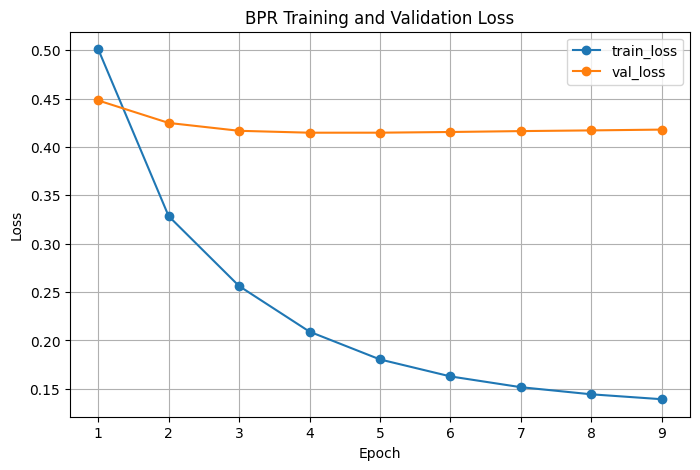

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BPR Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

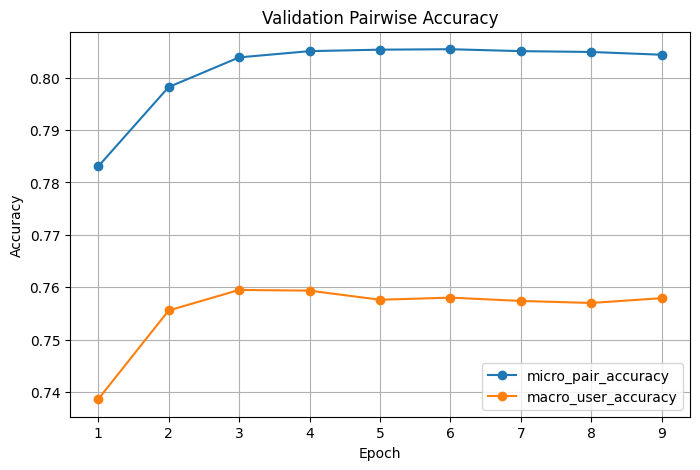

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["val_micro_pair_accuracy"],
    marker="o",
    label="micro_pair_accuracy"
)
plt.plot(
    history_df["epoch"],
    history_df["val_macro_user_accuracy"],
    marker="o",
    label="macro_user_accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Pairwise Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Save Step 2 Results

We save the trained BPR checkpoint, training history, test metrics, ID mappings, and learned embeddings. The embeddings will be reused in later steps for DBSCAN clustering, Bayesian pairwise classifiers, kNN baselines, and group recommendation.

In [29]:
step2_dir = "./results02"
os.makedirs(step2_dir, exist_ok=True)

history_df.to_csv(f"{step2_dir}/bpr_training_history.csv", index=False)
best_epoch_row.to_csv(f"{step2_dir}/bpr_best_epoch.csv", index=False)
test_metrics_df.to_csv(f"{step2_dir}/bpr_test_metrics.csv", index=False)

torch.save(model.state_dict(), f"{step2_dir}/bpr_model.pt")

with open(f"{step2_dir}/user_to_idx.pkl", "wb") as f:
    pickle.dump(user_to_idx, f)

with open(f"{step2_dir}/item_to_idx.pkl", "wb") as f:
    pickle.dump(item_to_idx, f)

with open(f"{step2_dir}/idx_to_user.pkl", "wb") as f:
    pickle.dump(idx_to_user, f)

with open(f"{step2_dir}/idx_to_item.pkl", "wb") as f:
    pickle.dump(idx_to_item, f)

user_embeddings = model.user_embeddings.weight.detach().cpu().numpy()
item_embeddings = model.item_embeddings.weight.detach().cpu().numpy()

np.save(f"{step2_dir}/user_embeddings.npy", user_embeddings)
np.save(f"{step2_dir}/item_embeddings.npy", item_embeddings)

with open(f"{step2_dir}/bpr_training_config.json", "w") as f:
    json.dump(training_config, f, indent=2)

save_summary = pd.DataFrame([
    {"artifact": "bpr_model.pt", "description": "Best BPR model checkpoint"},
    {"artifact": "bpr_training_history.csv", "description": "Training and validation metrics by epoch"},
    {"artifact": "bpr_best_epoch.csv", "description": "Best validation epoch selected by early stopping"},
    {"artifact": "bpr_test_metrics.csv", "description": "Final held-out test metrics"},
    {"artifact": "user_embeddings.npy", "description": "Learned user embedding matrix"},
    {"artifact": "item_embeddings.npy", "description": "Learned item embedding matrix"},
    {"artifact": "user_to_idx.pkl", "description": "Mapping from original user_id to compact user index"},
    {"artifact": "item_to_idx.pkl", "description": "Mapping from original movie_id to compact item index"},
    {"artifact": "idx_to_user.pkl", "description": "Reverse user index mapping"},
    {"artifact": "idx_to_item.pkl", "description": "Reverse item index mapping"},
    {"artifact": "bpr_training_config.json", "description": "Training hyperparameters"},
])

display(save_summary)

,artifact,description
0,bpr_model.pt,Best BPR model checkpoint
1,bpr_training_history.csv,Training and validation metrics by epoch
2,bpr_best_epoch.csv,Best validation epoch selected by early stopping
3,bpr_test_metrics.csv,Final held-out test metrics
4,user_embeddings.npy,Learned user embedding matrix
5,item_embeddings.npy,Learned item embedding matrix
6,user_to_idx.pkl,Mapping from original user_id to compact user ...
7,item_to_idx.pkl,Mapping from original movie_id to compact item...
8,idx_to_user.pkl,Reverse user index mapping
9,idx_to_item.pkl,Reverse item index mapping


## Step 2 Summary

We trained a pairwise matrix factorization model using BPR loss on triplets `(user, positive item, negative item)`. The positive item was defined as a movie rated at least two stars higher than the negative item.

The model improved substantially over the random initialization baseline. Early stopping selected epoch 4 as the best checkpoint based on validation BPR loss. The final model achieved strong pairwise ranking performance on the held-out test set, with test micro pair accuracy of 0.814 and test macro user accuracy of 0.772.

The gap between micro and macro accuracy shows that user activity imbalance still matters, but the macro result confirms that the model performs well when users are weighted more evenly. The learned user and item embeddings were saved for downstream DBSCAN clustering, Bayesian classifiers, kNN baselines, and group recommendation.